## Data loading and initial inspection

Load the news dataset and inspect columns, missing values, and a few sample rows. 

In [41]:
# Cell: Data load & inspection
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../Data/newsData/raw_analyst_ratings.csv")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.columns = [c.strip().lower() for c in df.columns]

print("Rows, Columns:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values per column:\n", df.isna().sum())
display(df.head(10))


Rows, Columns: (1407328, 6)

Columns: ['unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Missing values per column:
 unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


,unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A
8,8,Wells Fargo Maintains Overweight on Agilent Te...,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00,A
9,9,10 Biggest Price Target Changes For Friday,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,2020-05-22 08:06:17-04:00,A


### Descriptive statistics: Headline lengths

Compute basic statistics on headline lengths (characters and words). This helps understand text length distribution and detect outliers or unusually long headlines.


In [42]:
# Cell: Headline length stats
df['headline'] = df['headline'].fillna('').astype(str)
df['headline_len_chars'] = df['headline'].str.len()
df['headline_len_words'] = df['headline'].str.split().apply(len)

desc_chars = df['headline_len_chars'].describe()
desc_words = df['headline_len_words'].describe()
print("Headline length (chars):\n", desc_chars)
print("\nHeadline length (words):\n", desc_words)




Headline length (chars):
 count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len_chars, dtype: float64

Headline length (words):
 count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: headline_len_words, dtype: float64


### Publisher activity

Count number of articles per `publisher` to identify the most active publishers and potential sources of bias.


,publisher,n_articles
0,Paul Quintaro,228373
1,Lisa Levin,186979
2,Benzinga Newsdesk,150484
3,Charles Gross,96732
4,Monica Gerson,82380
5,Eddie Staley,57254
6,Hal Lindon,49047
7,ETF Professor,28489
8,Juan Lopez,28438
9,Benzinga Staff,28114


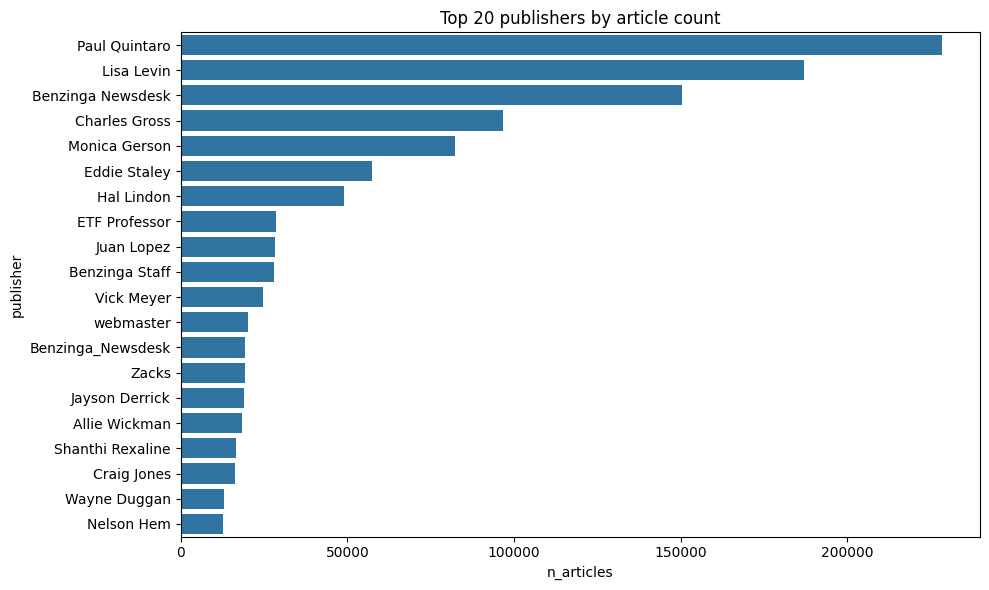

In [43]:
# Cell: Publisher counts
pub_counts = df['publisher'].fillna('Unknown').value_counts().reset_index()
pub_counts.columns = ['publisher','n_articles']
display(pub_counts.head(30))


import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=pub_counts.head(20), y='publisher', x='n_articles')
plt.title("Top 20 publishers by article count")
plt.tight_layout()
plt.show()


### Publication trends over time

Aggregate counts of articles by day to see frequency and spikes. This reveals busy news days or market event clustering.


,publish_date,n_articles
0,2011-04-27 00:00:00-04:00,1
1,2011-04-28 00:00:00-04:00,2
2,2011-04-29 00:00:00-04:00,2
3,2011-04-30 00:00:00-04:00,1
4,2011-05-01 00:00:00-04:00,1


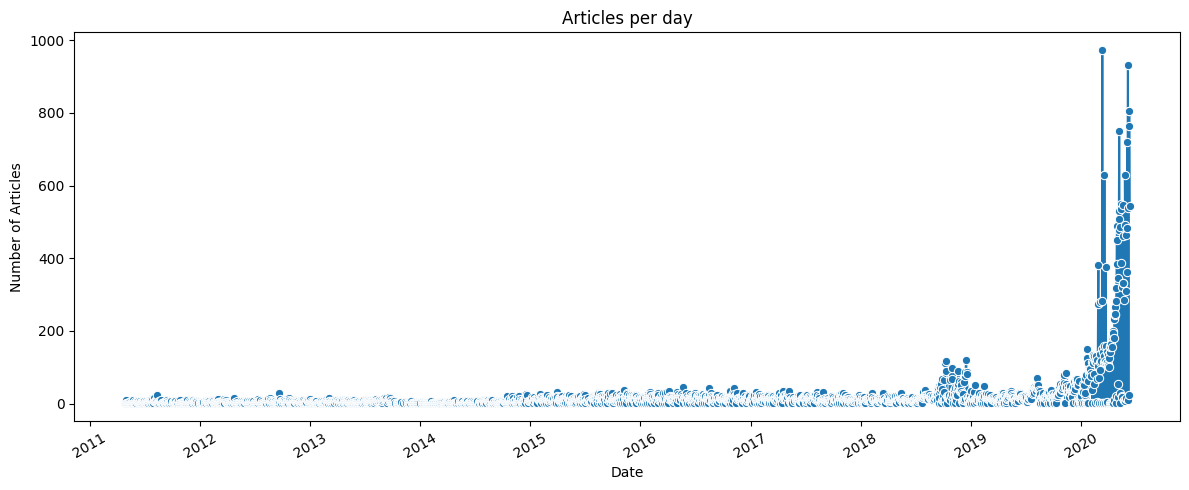

In [44]:


# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Create a daily publish_date column
df['publish_date'] = df['date'].dt.normalize()   # sets time to midnight

# Count articles per day
daily_counts = (
    df.groupby('publish_date')
      .size()
      .rename('n_articles')
      .reset_index()
)

display(daily_counts.head())

# Plot daily article counts
plt.figure(figsize=(12,5))
sns.lineplot(data=daily_counts, x='publish_date', y='n_articles', marker='o')
plt.title("Articles per day")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Time of day analysis

Check when during the day most headlines are released (hour of day). This is useful for trading strategies using intraday news.


,hour,n_articles
0,0,67
1,1,14
2,2,57
3,3,93
4,4,1469
5,5,1829
6,6,2476
7,7,5033
8,8,5527
9,9,5965


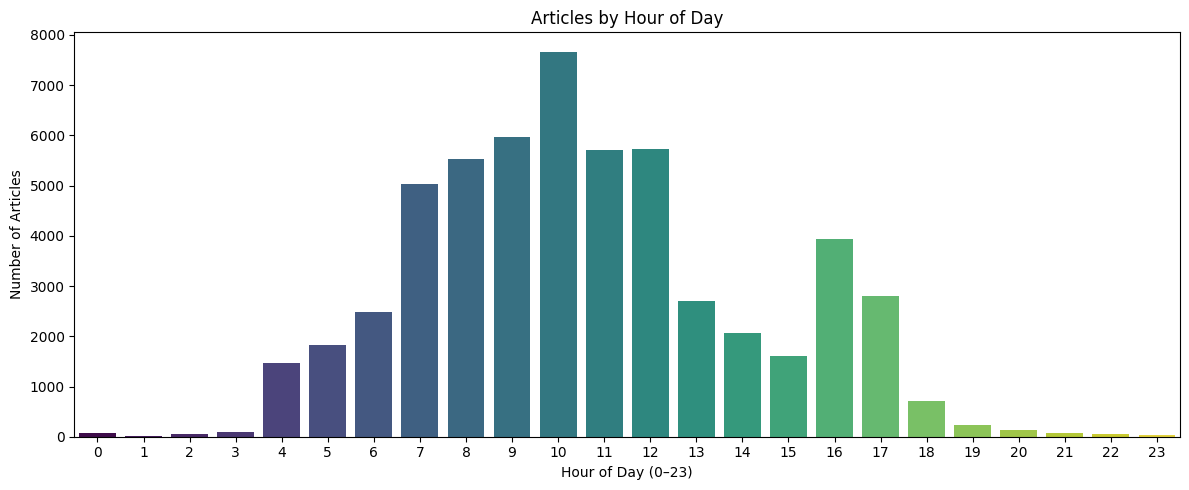

In [45]:
# Cell: Hour of day analysis

# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where 'date' could not be parsed
df = df.dropna(subset=['date'])

# Extract hour of day
df['hour'] = df['date'].dt.hour

# Count articles per hour
hour_counts = (
    df.groupby('hour')
      .size()
      .rename('n_articles')
      .reset_index()
      .sort_values('hour')
)

display(hour_counts)

# Plot hourly article counts
plt.figure(figsize=(12,5))
sns.barplot(
    x='hour',
    y='n_articles',
    data=hour_counts,
    hue='hour',          # assign x variable to hue
    palette="viridis",
    legend=False         # suppress redundant legend
)
plt.title("Articles by Hour of Day")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Number of Articles")
plt.xticks(range(0,24))  # show all hours on x-axis
plt.tight_layout()
plt.show()




### Top keywords and n-grams

Extract frequent unigrams and bigrams from headlines to surface common topics (e.g. "price target", "earnings beat", "FDA approval").


,term,count
4374,stocks,12794
4904,week,9029
451,52,8453
4134,shares,8393
454,52 week,8251
4653,trading,6575
2381,hit,5902
4377,stocks hit,5847
2382,hit 52,5846
1805,eps,5531


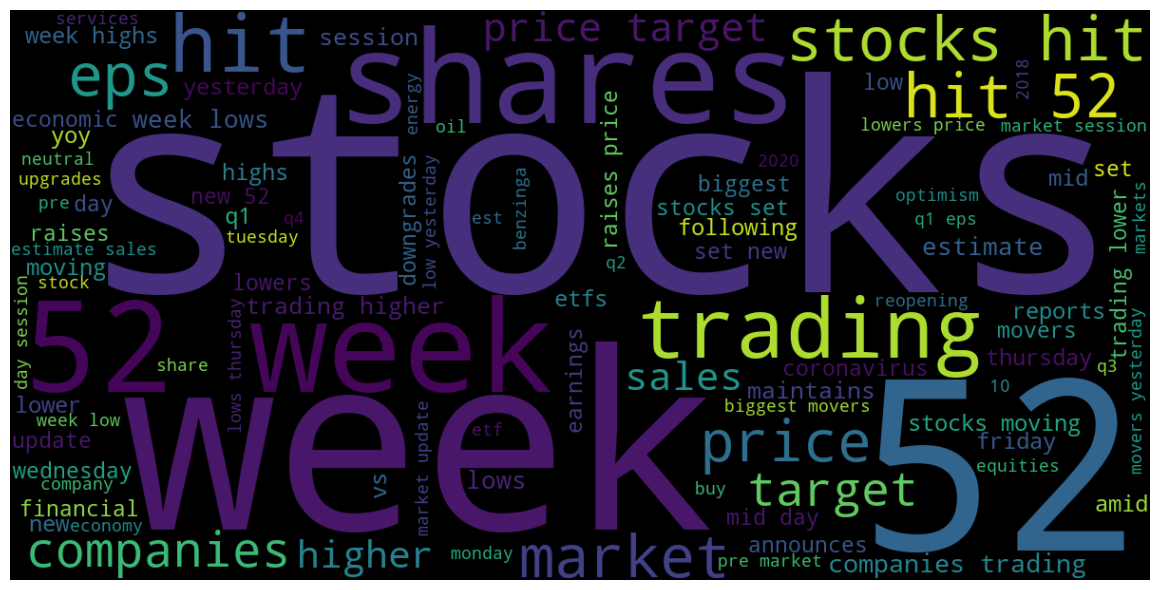

In [46]:
# Cell: Top n-grams
from sklearn.feature_extraction.text import CountVectorizer

docs = df['headline'].fillna('').astype(str).tolist()
vect = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
X = vect.fit_transform(docs)
sums = X.sum(axis=0).A1
terms = vect.get_feature_names_out()
freq_df = pd.DataFrame({'term': terms, 'count': sums}).sort_values('count', ascending=False)
display(freq_df.head(40))

# Wordcloud (optional)
from wordcloud import WordCloud
top = dict(zip(freq_df['term'].head(100), freq_df['count'].head(100)))
wc = WordCloud(width=1200, height=600).generate_from_frequencies(top)
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()


### Topic Modeling (LDA)

Run LDA on headline TF-IDF features. Short headlines make topic modeling less stable; consider aggregating headlines by day or publisher for better topics.


In [47]:
# Cell: LDA topic modelling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

tf = TfidfVectorizer(stop_words='english', max_features=2000)
X_tf = tf.fit_transform(docs)

n_topics = 6
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X_tf)

words = tf.get_feature_names_out()
topics = []
for i, comp in enumerate(lda.components_):
    terms_idx = comp.argsort()[-10:][::-1]
    topic_terms = [words[idx] for idx in terms_idx]
    topics.append(topic_terms)
    print(f"Topic {i}: {', '.join(topic_terms)}")




Topic 0: eps, moving, session, estimate, sales, yoy, q1, stocks, day, pre
Topic 1: etfs, new, etf, set, low, stocks, week, yesterday, 2018, 52
Topic 2: hit, 52, week, stocks, lows, highs, thursday, movers, biggest, friday
Topic 3: shares, trading, companies, higher, market, amid, lower, following, update, oil
Topic 4: price, target, maintains, raises, lowers, buy, neutral, downgrades, morgan, outperform
Topic 5: share, announces, reports, says, deal, stock, biotech, shares, merger, ex


### Time series event detection (spikes)

Identify days where article frequency is significantly higher than baseline (e.g., > mean + 2*std). These are candidate market-event days to inspect.


In [48]:
# Cell: Spike detection
daily = daily_counts.copy()
mean = daily['n_articles'].mean()
std = daily['n_articles'].std()
threshold = mean + 2*std
spikes = daily[daily['n_articles'] > threshold]
print(f"Threshold = {threshold:.2f}. Spikes found: {len(spikes)}")
display(spikes)



Threshold = 158.43. Spikes found: 51


,publish_date,n_articles
2425,2020-02-27 00:00:00-04:00,275
2426,2020-02-28 00:00:00-04:00,381
2433,2020-03-06 00:00:00-04:00,281
2437,2020-03-11 00:00:00-04:00,282
2438,2020-03-12 00:00:00-04:00,973
2445,2020-03-19 00:00:00-04:00,629
2449,2020-03-23 00:00:00-04:00,375
2450,2020-03-24 00:00:00-04:00,160
2465,2020-04-09 00:00:00-04:00,164
2468,2020-04-13 00:00:00-04:00,184


### Publisher analysis and domains

Extract domains if publisher entries contain emails; otherwise inspect publisher names by frequency and sample headlines from top publishers to check coverage/bias.


In [49]:
# Cell: Publisher domain extraction and sample headlines
import re
pubs = df['publisher'].fillna('').astype(str)
domains = pubs.str.extract(r'@([^\s>]+)')[0].dropna()
if not domains.empty:
    dom_counts = domains.value_counts().reset_index()
    dom_counts.columns = ['domain','n_articles']
    display(dom_counts.head(20))
    
else:
    print("No email-like publisher entries. Showing top publishers and sample headlines.")
    display(pub_counts.head(20))
    # sample headlines per top publisher
    top_pubs = pub_counts['publisher'].head(5).tolist()
    for p in top_pubs:
        print(f"\n=== Sample headlines for publisher: {p} ===")
        display(df[df['publisher']==p]['headline'].head(6))


,domain,n_articles
0,benzinga.com,1196
1,gmail.com,3


### Article coverage per stock

Count articles per `stock` ticker to see which symbols have most coverage.


,stock,n_articles
0,ZX,10
1,A,10
2,AA,10
3,AAC,10
4,ZUMZ,10
5,AAL,10
6,AAMC,10
7,AAME,10
8,AAN,10
9,AAOI,10


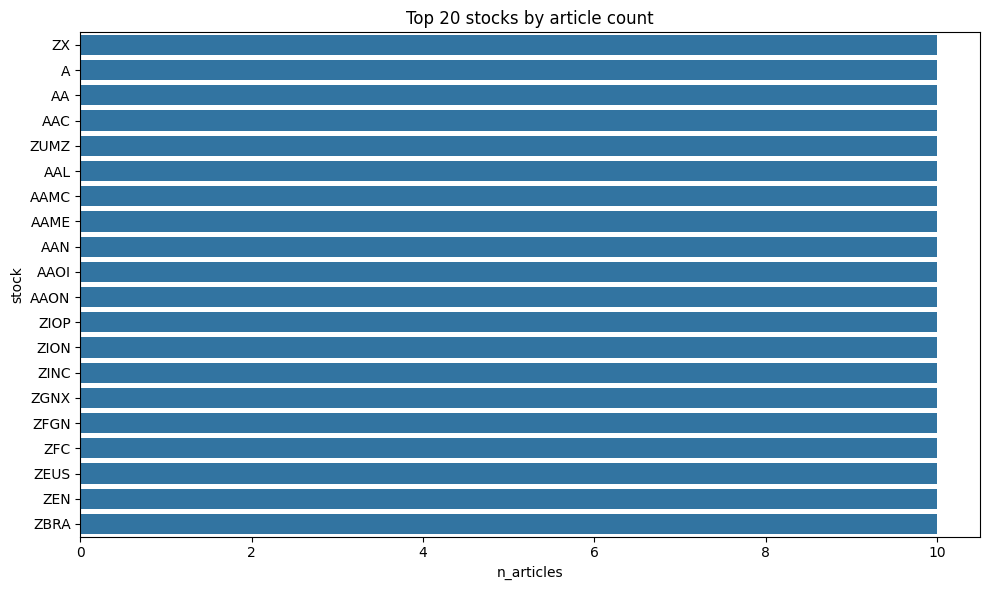

In [50]:
# Cell: Stock coverage
stock_counts = df['stock'].fillna('UNKNOWN').value_counts().reset_index()
stock_counts.columns = ['stock','n_articles']
display(stock_counts.head(30))

plt.figure(figsize=(10,6))
sns.barplot(data=stock_counts.head(20), x='n_articles', y='stock')
plt.title("Top 20 stocks by article count")
plt.tight_layout()
plt.show()
